# Replikasi Eksperimen Giudici et al. (2020)
## *Network Models to Improve Automated Cryptocurrency Portfolio Management*

Notebook ini membandingkan strategi portofolio berikut:
1. **Equally Weighted (EW)** — Portofolio naif (1/N)
2. **Classical Markowitz (CM)** — Optimasi Mean-Variance tradisional
3. **Glasso Markowitz (GM)** — Markowitz + regularisasi Graphical Lasso
4. **Network Markowitz (NW)** — Integrasi RMT + MST dengan penalti sentralitas γ

---
## Sel 1 — Persiapan Library

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.optimize import minimize
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.linalg import eigh
from sklearn.covariance import GraphicalLassoCV
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Sel 2 — Memuat Data

Memuat data return dan harga dari file Excel. Fokus utama adalah pada dataset return harian untuk 10 aset kripto utama dalam periode 14 September 2017 hingga 17 Oktober 2019.

In [67]:
# Load data
excel_file = 'crypto_data_real.xlsx'
df_returns = pd.read_excel(excel_file, sheet_name='Returns', index_col=0)
df_prices  = pd.read_excel(excel_file, sheet_name='Prices',  index_col=0)

crypto_names = df_returns.columns.tolist()
n_assets     = len(crypto_names)

print(f"Data loaded: {df_returns.shape[0]} days, {n_assets} assets")
print(f"Period: {df_returns.index[0]} to {df_returns.index[-1]}")
print(f"Assets: {crypto_names}")

Data loaded: 763 days, 10 assets
Period: 2017-09-15 00:00:00 to 2019-10-17 00:00:00
Assets: ['BTC', 'ETH', 'XRP', 'USDT', 'BCH', 'LTC', 'BNB', 'EOS', 'XLM', 'TRX']


---
## Sel 3 — Statistik Ringkasan (TABLE 1)

Menghasilkan tabel statistik deskriptif: Mean, Standar Deviasi, Kurtosis, dan Skewness.

In [68]:
# Create summary statistics table
summary_stats = pd.DataFrame({
    'Mean':     df_returns.mean(),
    'Std':      df_returns.std(),
    'Kurtosis': df_returns.kurt(),
    'Skewness': df_returns.skew()
})

print("TABLE 1 | Summary statistics.")
print(summary_stats.round(4))

TABLE 1 | Summary statistics.
        Mean     Std  Kurtosis  Skewness
BTC   0.0012  0.0434    3.0822    0.0523
ETH  -0.0008  0.0507    2.8209   -0.2916
XRP   0.0004  0.0654   18.9009    2.0588
USDT -0.0000  0.0057   21.7209    0.7437
BCH  -0.0014  0.0724    7.5671    0.6231
LTC   0.0004  0.0585    6.6357    1.0988
BNB   0.0029  0.0621   10.2612    1.0694
EOS   0.0012  0.0709    4.7582    0.5781
XLM   0.0006  0.0657    7.0332    0.9799
TRX   0.0025  0.0879   22.1856    2.6905


---
## Sel 4 — Visualisasi Harga Ternormalisasi (Figure 1 & 2)

Mereplikasi *Normalized cryptocurrency price series* dengan mengatur harga awal setiap aset menjadi 100.

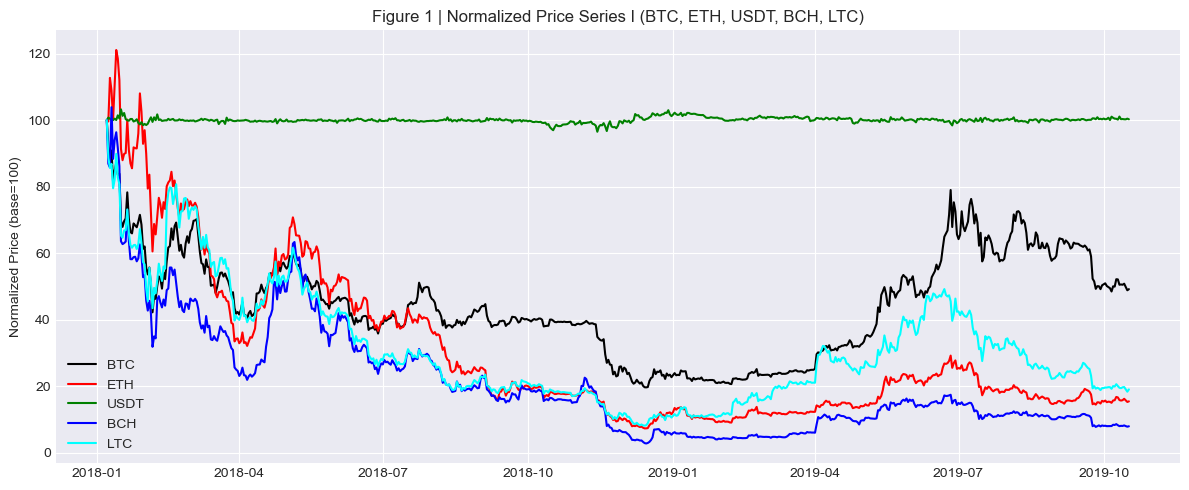

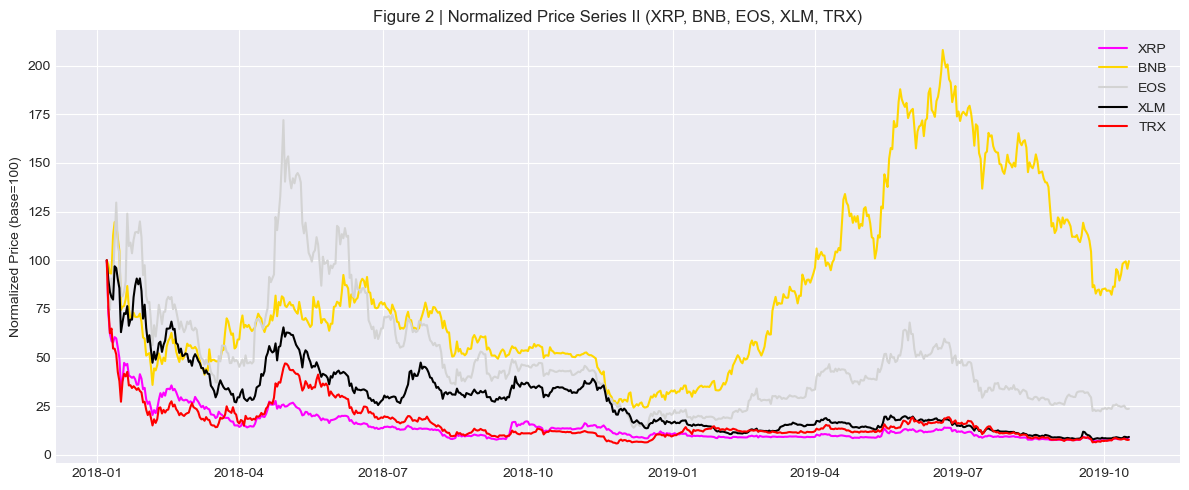

In [69]:
# --- Figure 1: BTC, ETH, USDT, BCH, LTC ---
assets_1   = ['BTC', 'ETH', 'USDT', 'BCH', 'LTC']
df_norm_1  = (df_prices.loc['2018-01-07':, assets_1] / df_prices.loc['2018-01-07', assets_1]) * 100
colors_1   = ['black', 'red', 'green', 'blue', 'cyan']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_1.columns):
    plt.plot(df_norm_1.index, df_norm_1[col], label=col, color=colors_1[i])
plt.title('Figure 1 | Normalized Price Series I (BTC, ETH, USDT, BCH, LTC)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

# --- Figure 2: XRP, BNB, EOS, XLM, TRX ---
assets_2  = ['XRP', 'BNB', 'EOS', 'XLM', 'TRX']
df_norm_2 = (df_prices.loc['2018-01-07':, assets_2] / df_prices.loc['2018-01-07', assets_2]) * 100
colors_2  = ['magenta', 'gold', 'lightgrey', 'black', 'red']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_2.columns):
    plt.plot(df_norm_2.index, df_norm_2[col], label=col, color=colors_2[i])
plt.title('Figure 2 | Normalized Price Series II (XRP, BNB, EOS, XLM, TRX)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

---
## Sel 5 — Visualisasi Minimum Spanning Tree (Figure 3 & 4)

Mereplikasi struktur jaringan aset kripto pada periode *speculative bubble* (Sep 2017 – Jan 2018) dan periode stabil (Jun 2019 – Okt 2019).

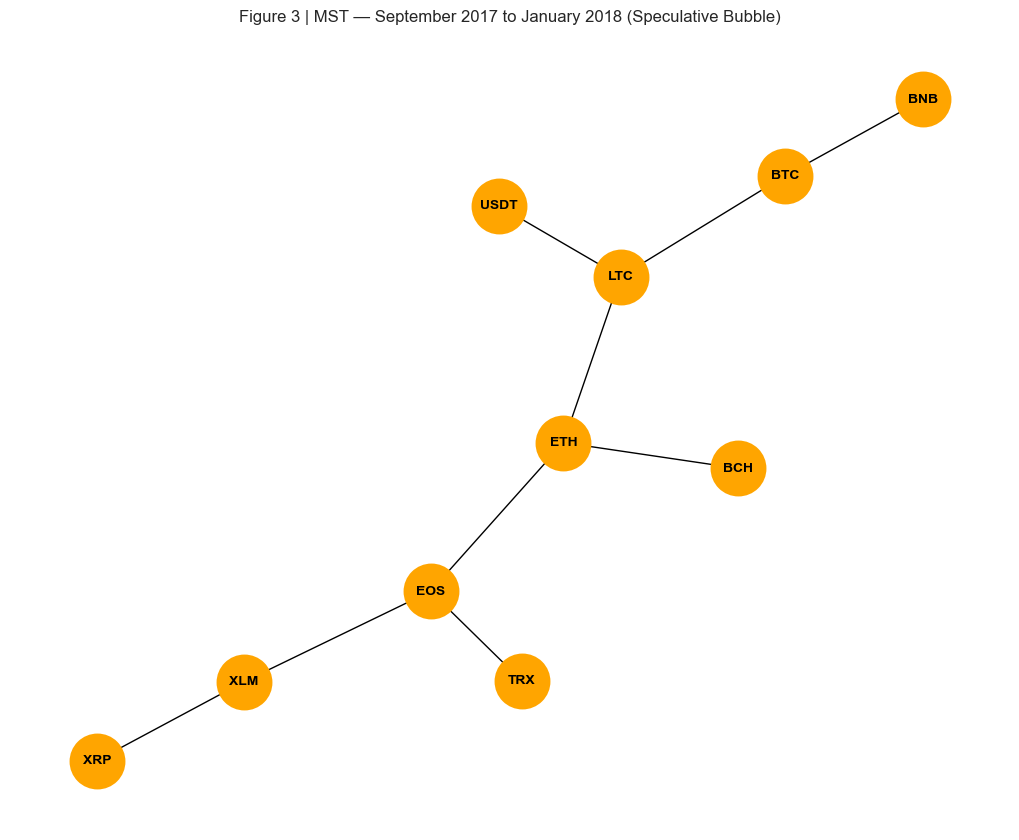

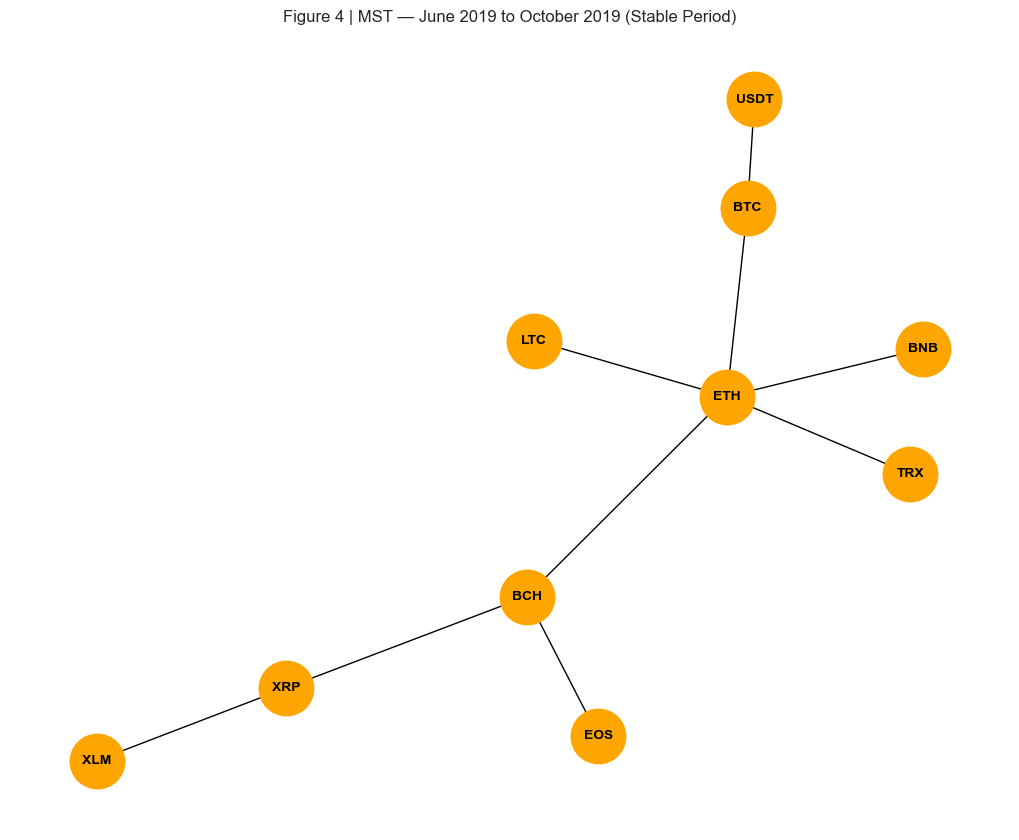

In [70]:
# --- Figure 3 | MST: Speculative Bubble Period ---
df_bubble   = df_returns.loc['2017-09-14':'2018-01-31']
corr_bubble = df_bubble.corr()
dist_bubble = np.sqrt(2 * (1 - corr_bubble))

G          = nx.from_pandas_adjacency(dist_bubble)
mst_bubble = nx.minimum_spanning_tree(G, weight='weight')

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(mst_bubble, seed=42)
nx.draw(mst_bubble, pos, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 3 | MST — September 2017 to January 2018 (Speculative Bubble)', fontsize=12)
plt.tight_layout()
plt.show()

# --- Figure 4 | MST: Stable Period ---
df_stable   = df_returns.loc['2019-06-01':'2019-10-17']
corr_stable = df_stable.corr()
dist_stable = np.sqrt(2 * (1 - corr_stable))

G2         = nx.from_pandas_adjacency(dist_stable)
mst_stable = nx.minimum_spanning_tree(G2, weight='weight')

plt.figure(figsize=(10, 8))
pos2 = nx.spring_layout(mst_stable, seed=42)
nx.draw(mst_stable, pos2, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 4 | MST — June 2019 to October 2019 (Stable Period)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Sel 6 — Fungsi Pembantu (Helper Functions)

Implementasi algoritma:
- **RMT Filter** — penyaringan noise pada matriks korelasi
- **MST Distance** — konstruksi jarak antar aset
- **Eigenvector Centrality** — mengukur pentingnya setiap aset dalam jaringan
- **VaR, Rachev Ratio, Max Drawdown** — metrik risiko

In [71]:
def apply_rmt_filter(returns_data):
    """Filter noise dari matriks korelasi menggunakan Random Matrix Theory."""
    if isinstance(returns_data, pd.DataFrame):
        data = returns_data.values
    else:
        data = returns_data
    T, N = data.shape
    Q    = T / N
    C    = np.corrcoef(data.T)

    eigenvalues, eigenvectors = eigh(C)
    eigenvalues  = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]

    lambda_plus      = 1 + (1/Q) + 2*np.sqrt(1/Q)          # Marcenko-Pastur upper bound
    significant_mask = eigenvalues > lambda_plus
    Lambda_filtered  = np.diag(np.where(significant_mask, eigenvalues, 0))
    C_filtered       = eigenvectors @ Lambda_filtered @ eigenvectors.T
    return C_filtered


def build_mst(correlation_matrix):
    """Hitung matriks jarak dari matriks korelasi untuk MST."""
    distance_matrix = np.sqrt(2 - 2 * correlation_matrix)
    np.fill_diagonal(distance_matrix, 0)
    return distance_matrix


def compute_eigenvector_centrality(distance_matrix):
    """Hitung sentralitas eigenvector dari matriks jarak."""
    adjacency = 1 / (distance_matrix + 1e-8)
    np.fill_diagonal(adjacency, 0)
    eigenvalues, eigenvectors = eigh(adjacency)
    principal_eigenvector     = np.abs(eigenvectors[:, -1])
    centrality                = principal_eigenvector / principal_eigenvector.sum()
    return centrality


def calculate_var(returns, confidence=0.95):
    """Value at Risk pada tingkat kepercayaan tertentu."""
    return np.percentile(returns, (1 - confidence) * 100)


def calculate_rachev_ratio(returns, alpha=0.10):
    """Rachev Ratio: rata-rata gain ekor atas / rata-rata loss ekor bawah."""
    threshold_upper = np.percentile(returns, (1 - alpha) * 100)
    threshold_lower = np.percentile(returns, alpha * 100)
    cvar_upper      = returns[returns >= threshold_upper].mean()
    cvar_lower      = abs(returns[returns <= threshold_lower].mean())
    return cvar_upper / cvar_lower if cvar_lower > 0 else 0


def calculate_max_drawdown(cumulative_returns):
    """Maximum drawdown dari seri kumulatif."""
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdown    = (cumulative_returns - running_max) / running_max
    return drawdown.min()


print("Helper functions defined successfully!")

Helper functions defined successfully!


---
## Sel New — Analisis Dinamika MST (Figure 5)

Rolling window untuk menghitung evolusi *max link distance* dan koefisien *residuality* dari MST sepanjang waktu.

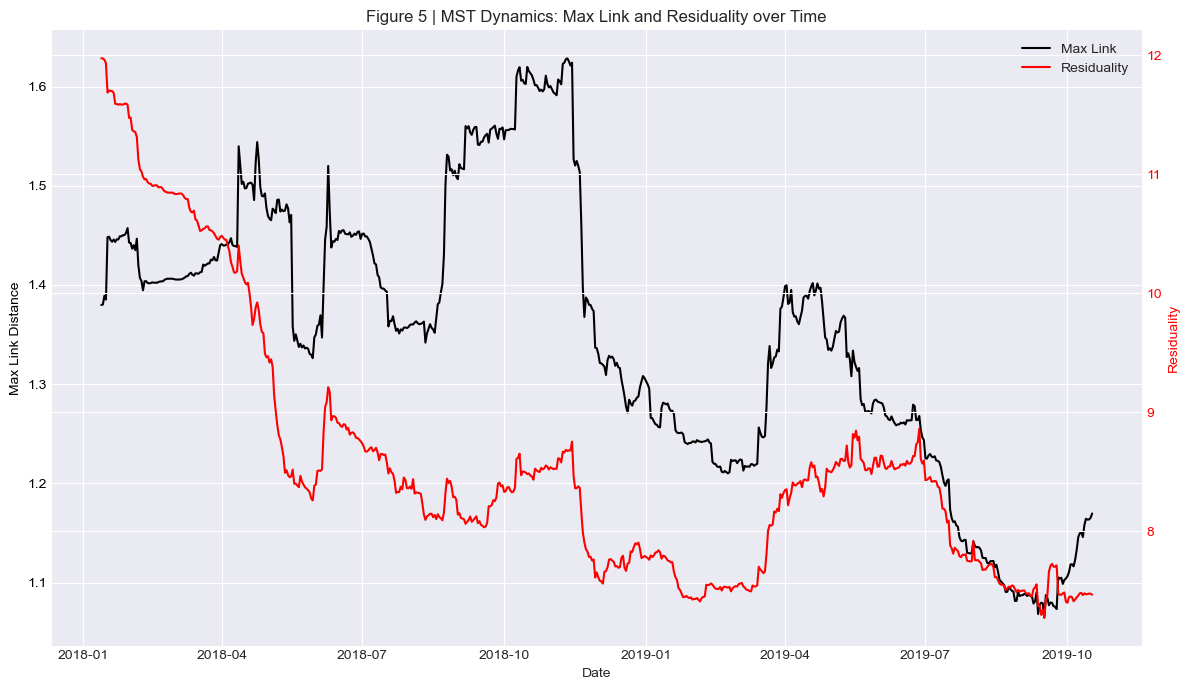

In [72]:
def calculate_rolling_mst_metrics(returns_df, window=120):
    """Hitung dinamika MST dengan rolling window."""
    dates         = returns_df.index[window:]
    max_links     = []
    residualities = []

    for i in range(window, len(returns_df)):
        window_data  = returns_df.iloc[i - window:i]
        corr_f       = apply_rmt_filter(window_data)
        mst_weights  = build_mst(corr_f)
        max_links.append(np.max(mst_weights))
        residualities.append(np.sum(mst_weights) / (returns_df.shape[1] - 1))

    return pd.DataFrame(
        {'Max Link': max_links, 'Residuality': residualities},
        index=dates
    )


mst_dyn = calculate_rolling_mst_metrics(df_returns)

# --- Figure 5: Dual-axis plot ---
fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.plot(mst_dyn.index, mst_dyn['Max Link'], color='black', label='Max Link')
ax1.set_xlabel('Date')
ax1.set_ylabel('Max Link Distance', color='black')
ax1.tick_params(axis='y', labelcolor='black')

ax2 = ax1.twinx()
ax2.plot(mst_dyn.index, mst_dyn['Residuality'], color='red', label='Residuality')
ax2.set_ylabel('Residuality', color='red')
ax2.tick_params(axis='y', labelcolor='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Figure 5 | MST Dynamics: Max Link and Residuality over Time', fontsize=12)
plt.tight_layout()
plt.savefig('figure_5_mst_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sel 7 — Implementasi Strategi Portofolio

Setiap strategi diatur dalam kelas yang mewarisi `PortfolioStrategy`. **Network Markowitz** mencakup penalti sentralitas melalui parameter γ.

In [73]:
class PortfolioStrategy:
    def __init__(self, name):
        self.name            = name
        self.weights_history = []
        self.returns_history = []

    def get_weights(self, returns_data):
        raise NotImplementedError


class EquallyWeighted(PortfolioStrategy):
    """Strategi naif: bobot sama untuk semua aset (1/N)."""
    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        return np.ones(n) / n


class ClassicalMarkowitz(PortfolioStrategy):
    """Optimasi Mean-Variance tradisional (minimasi varians portofolio)."""
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        mu       = returns_data.mean().values
        S        = returns_data.cov().values

        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(n_assets) / n_assets,
                       method='SLSQP', bounds=[(0, 1)] * n_assets,
                       constraints=constraints)
        return res.x if res.success else np.ones(n_assets) / n_assets


class GlassoMarkowitz(PortfolioStrategy):
    """Markowitz dengan matriks presisi yang diestimasi via Graphical Lasso."""
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        mu       = returns_data.mean().values

        try:
            glasso    = GraphicalLassoCV()
            glasso.fit(returns_data.values)
            S = glasso.covariance_
        except Exception:
            S = returns_data.cov().values

        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(n_assets) / n_assets,
                       method='SLSQP', bounds=[(0, 1)] * n_assets,
                       constraints=constraints)
        return res.x if res.success else np.ones(n_assets) / n_assets


class NetworkMarkowitz(PortfolioStrategy):
    """Network Markowitz: RMT + MST + penalti sentralitas eigenvector."""
    def __init__(self, name="Network Markowitz", gamma=0):
        super().__init__(name)
        self.gamma = gamma

    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        mu       = returns_data.mean().values
        sig      = returns_data.std().values

        Cf   = apply_rmt_filter(returns_data)
        dist = build_mst(Cf)
        cent = compute_eigenvector_centrality(dist)
        Sf   = np.outer(sig, sig) * Cf

        objective   = lambda w: w @ Sf @ w + self.gamma * np.sum(cent * w)
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(n_assets) / n_assets,
                       method='SLSQP', bounds=[(0, 1)] * n_assets,
                       constraints=constraints)
        return res.x if res.success else np.ones(n_assets) / n_assets


print("Strategy classes defined successfully!")

Strategy classes defined successfully!


---
## Sel 8 — Framework Backtesting

Rolling window dengan *transaction cost* 0.1% (10 basis points) per rebalancing.

In [74]:
def backtest_strategy(strategy, df_returns,
                      window_size=120, rebalance_freq=7,
                      transaction_cost=0.001):
    """
    Simulasi backtesting dengan rolling window.
    
    Parameters
    ----------
    strategy         : PortfolioStrategy — objek strategi
    df_returns       : pd.DataFrame      — data return harian
    window_size      : int               — panjang jendela training (hari)
    rebalance_freq   : int               — frekuensi rebalancing (hari)
    transaction_cost : float             — biaya transaksi per rebalancing
    """
    portfolio_returns = []
    dates             = []

    for i in range(window_size, len(df_returns), rebalance_freq):
        train = df_returns.iloc[i - window_size:i]
        w     = strategy.get_weights(train)

        test_end  = min(i + rebalance_freq, len(df_returns))
        test_data = df_returns.iloc[i:test_end]

        for j in range(len(test_data)):
            daily_ret = np.dot(w, test_data.iloc[j].values)
            if j == 0 and len(portfolio_returns) > 0:
                daily_ret -= transaction_cost   # Biaya transaksi saat rebalancing
            portfolio_returns.append(daily_ret)
            dates.append(test_data.index[j])

    res_df = pd.DataFrame({'date': dates, 'return': portfolio_returns})
    res_df['cumulative_return'] = (1 + res_df['return']).cumprod()

    return {
        'strategy':           strategy.name,
        'returns':            np.array(portfolio_returns),
        'cumulative_returns': res_df['cumulative_return'].values,
        'results_df':         res_df
    }


print("Backtest function defined successfully!")

Backtest function defined successfully!


---
## Sel 9 — Eksekusi Backtesting

Inisialisasi semua strategi dan jalankan simulasi backtesting, termasuk berbagai nilai penalti γ untuk Network Markowitz.

In [75]:
# --- Inisialisasi strategi ---
gamma_values = [0.005, 0.025, 0.05, 0.15, 0.7, 1.0]

strategies = [
    EquallyWeighted("EW"),
    ClassicalMarkowitz("CM"),
    GlassoMarkowitz("GM"),
    NetworkMarkowitz("NW (γ=0)", gamma=0),
] + [
    NetworkMarkowitz(f"NW (γ={g})", gamma=g) for g in gamma_values
]

# --- Eksekusi backtest ---
results = {}
for strat in strategies:
    print(f"Running backtest: {strat.name} ...", end=" ")
    results[strat.name] = backtest_strategy(strat, df_returns,
                                            window_size=120,
                                            rebalance_freq=7,
                                            transaction_cost=0.001)
    print("Done")

print("\nAll backtests completed!")

Running backtest: EW ... Done
Running backtest: CM ... Done
Running backtest: GM ... Done
Running backtest: NW (γ=0) ... Done
Running backtest: NW (γ=0.005) ... Done
Running backtest: NW (γ=0.025) ... Done
Running backtest: NW (γ=0.05) ... Done
Running backtest: NW (γ=0.15) ... Done
Running backtest: NW (γ=0.7) ... Done
Running backtest: NW (γ=1.0) ... Done

All backtests completed!


---
## Sel 10 — Analisis Performa Periodik (TABLE 2)

Tabel perbandingan *cumulative profit/loss* yang disampel setiap 4 bulan (Januari, Mei, September).

In [76]:
# Target dates: setiap akhir Januari, Mei, September
target_dates = [
    '2018-01-31', '2018-05-31', '2018-09-28',
    '2019-01-31', '2019-05-31', '2019-09-30'
]

table2_rows = []

for strat_name, res in results.items():
    df_res   = res['results_df'].set_index('date')
    row      = {'Strategy': strat_name}

    for td in target_dates:
        # Cari tanggal terdekat yang tersedia
        idx = df_res.index.searchsorted(pd.Timestamp(td))
        idx = min(idx, len(df_res) - 1)
        cum_ret = (df_res['cumulative_return'].iloc[idx] - 1) * 100
        row[td] = round(cum_ret, 2)

    table2_rows.append(row)

table2 = pd.DataFrame(table2_rows).set_index('Strategy')
table2.columns = ['Jan-18', 'May-18', 'Sep-18', 'Jan-19', 'May-19', 'Sep-19']

print("TABLE 2 | Cumulative Profits and Losses (%) at key dates")
print(table2.to_string())

TABLE 2 | Cumulative Profits and Losses (%) at key dates
              Jan-18  May-18  Sep-18  Jan-19  May-19  Sep-19
Strategy                                                    
EW            -35.53  -58.96  -77.26  -89.67  -77.88  -88.82
CM            -34.32  -57.88  -59.56  -68.22  -55.67  -62.16
GM            -33.86  -60.11  -61.81  -73.12  -62.49  -67.53
NW (γ=0)      -41.59  -62.30  -63.75  -71.79  -61.83  -68.05
NW (γ=0.005)  -41.62  -61.76  -64.14  -71.33  -62.41  -68.75
NW (γ=0.025)  -44.13  -64.87  -66.22  -66.72  -57.08  -66.33
NW (γ=0.05)   -44.80  -63.44  -64.53  -65.06  -55.14  -61.98
NW (γ=0.15)   -44.65  -56.79  -58.09  -58.72  -46.94  -54.22
NW (γ=0.7)    -40.13  -52.75  -54.11  -54.80  -41.90  -48.76
NW (γ=1.0)    -39.09  -51.94  -53.48  -54.17  -41.10  -48.05


---
## Sel 11 — Visualisasi Performa Kumulatif (FIGURE 6)

Evolusi nilai portofolio (skala 100 USD) untuk seluruh periode backtesting.

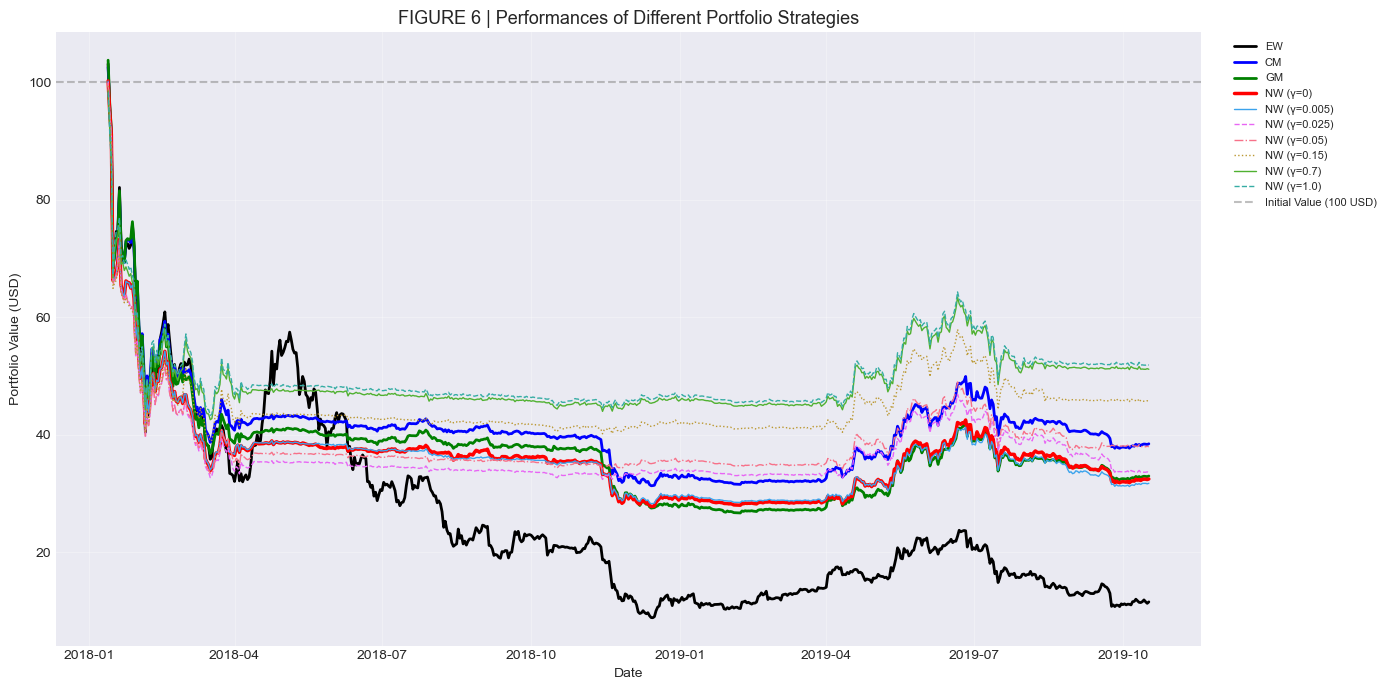

In [77]:
plt.figure(figsize=(14, 7))

# Highlight strategi utama
highlight  = {'EW': ('black', 2.0), 'CM': ('blue', 2.0),
               'GM': ('green', 2.0), 'NW (γ=0)': ('red', 2.5)}
linestyles = ['-', '--', '-.', ':']

for idx, (name, res) in enumerate(results.items()):
    df_res  = res['results_df']
    y_vals  = df_res['cumulative_return'].values * 100  # Skala 100 USD
    color   = highlight.get(name, (f'C{idx}',))[0]
    lw      = highlight.get(name, (None, 1.0))[1] if name in highlight else 1.0
    ls      = '-' if name in highlight else linestyles[idx % len(linestyles)]
    plt.plot(df_res['date'], y_vals, label=name, color=color, linewidth=lw, linestyle=ls)

plt.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='Initial Value (100 USD)')
plt.title('FIGURE 6 | Performances of Different Portfolio Strategies', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sel 12 — Ringkasan Metrik Performa

Tabel metrik akhir: Total Return, Sharpe Ratio, VaR, Rachev Ratio, dan Max Drawdown.

In [78]:
perf_rows = []

for name, res in results.items():
    r    = res['returns']
    cum  = res['cumulative_returns']

    total_ret    = (cum[-1] - 1) * 100
    sharpe       = (r.mean() / r.std()) * np.sqrt(252) if r.std() > 0 else 0
    var_95       = calculate_var(r, confidence=0.95) * 100
    rachev       = calculate_rachev_ratio(r)
    max_dd       = calculate_max_drawdown(cum) * 100

    perf_rows.append({
        'Strategy':      name,
        'Total Return%': round(total_ret, 2),
        'Sharpe Ratio':  round(sharpe, 4),
        'VaR 95% (%)':   round(var_95, 4),
        'Rachev Ratio':  round(rachev, 4),
        'Max Drawdown%': round(max_dd, 2)
    })

perf_df = pd.DataFrame(perf_rows).set_index('Strategy')
print("Performance Summary")
print(perf_df.to_string())

Performance Summary
              Total Return%  Sharpe Ratio  VaR 95% (%)  Rachev Ratio  Max Drawdown%
Strategy                                                                           
EW                   -88.49       -0.8646      -7.7519        0.8014         -91.45
CM                   -61.56       -0.8464      -3.6092        0.7734         -69.50
GM                   -67.05       -0.9317      -4.2237        0.7402         -74.31
NW (γ=0)             -67.56       -1.0727      -3.1887        0.7487         -72.30
NW (γ=0.005)         -68.30       -1.1153      -3.1950        0.7478         -71.82
NW (γ=0.025)         -66.40       -1.0766      -2.8866        0.7596         -67.66
NW (γ=0.05)          -62.06       -0.9426      -2.8433        0.7834         -66.58
NW (γ=0.15)          -54.32       -0.7117      -2.7887        0.8507         -60.86
NW (γ=0.7)           -48.87       -0.6244      -2.7660        0.8750         -56.81
NW (γ=1.0)           -48.16       -0.6127      -2.7660  

In [79]:
print("\nTABLE 3 | Value at Risk (95% Confidence, 4-Month Periods)")

# Tanggal target
target_dates = ['2018-01-31', '2018-05-31', '2018-09-30', 
                '2019-01-31', '2019-05-31', '2019-09-30']
target_labels = ['Jan-2018', 'May-2018', 'Sep-2018', 
                 'Jan-2019', 'May-2019', 'Sep-2019']

var_data = []

for d_str, label in zip(target_dates, target_labels):
    row = {'Period': label}
    dt = pd.to_datetime(d_str)
    
    # Looping otomatis ke SEMUA strategi yang ada di results
    for name, res in results.items():
        df_res = res['results_df']
        # Ambil jendela 4 bulan terakhir
        mask = (df_res['date'] <= dt) & (df_res['date'] > dt - pd.Timedelta(days=120))
        returns_segment = df_res.loc[mask, 'return'].values
        
        if len(returns_segment) > 0:
            # Nilai absolut VaR * 100
            v = abs(np.percentile(returns_segment, 5)) * 100
            row[name] = f"{v:.2f}"
        else:
            row[name] = "-"
    
    var_data.append(row)

table_3_df = pd.DataFrame(var_data)

# Urutkan kolom agar CRIX, EW, NW, GM, CM di depan, lalu diikuti gamma lainnya
base_cols = ['Period', 'CRIX', 'GM', 'EW', 'CM', 'NW']
other_cols = [c for c in table_3_df.columns if c not in base_cols]
# Filter hanya kolom yang benar-benar ada di hasil
final_cols = [c for c in base_cols if c in table_3_df.columns] + other_cols

table_3_df = table_3_df[final_cols]

print("=" * 120)
print(table_3_df.to_string(index=False))
print("-" * 120)
print("Note: Values are absolute VaR (95%) multiplied by a scale factor of 100.")



TABLE 3 | Value at Risk (95% Confidence, 4-Month Periods)
  Period    GM    EW    CM NW (γ=0) NW (γ=0.005) NW (γ=0.025) NW (γ=0.05) NW (γ=0.15) NW (γ=0.7) NW (γ=1.0)
Jan-2018 13.46 13.79 12.83    12.47        12.42        12.44       12.18       11.63      10.45      10.35
May-2018  5.93  9.55  5.80     5.62         5.61         5.91        5.60        5.62       5.62       5.62
Sep-2018  1.19  6.56  1.00     1.16         0.82         0.70        0.70        0.70       0.70       0.70
Jan-2019  2.46  9.59  1.73     1.86         1.69         0.96        0.96        0.96       0.96       0.96
May-2019  1.84  3.68  1.70     1.51         1.49         1.25        1.25        1.28       1.28       1.28
Sep-2019  4.31  8.29  3.86     4.03         3.50         3.22        3.07        3.21       3.07       3.07
------------------------------------------------------------------------------------------------------------------------
Note: Values are absolute VaR (95%) multiplied by a scale factor

In [80]:
print("\nTABLE 4 | Sharpe ratio (Periodic Comparison)")

# Tanggal target (Jan, Mei, Sep)
target_dates = ['2018-01-31', '2018-05-31', '2018-09-30', 
                '2019-01-31', '2019-05-31', '2019-09-30']
target_labels = ['Jan-2018', 'May-2018', 'Sep-2018', 
                 'Jan-2019', 'May-2019', 'Sep-2019']

sharpe_data = []

for d_str, label in zip(target_dates, target_labels):
    row = {'Period': label}
    dt = pd.to_datetime(d_str)
    
    for name, res in results.items():
        if name == 'CRIX': continue # Gambar di paper tidak menampilkan CRIX di Tabel 4
        
        df_res = res['results_df']
        # Jendela 4 bulan (120 hari)
        mask = (df_res['date'] <= dt) & (df_res['date'] > dt - pd.Timedelta(days=120))
        returns_segment = df_res.loc[mask, 'return'].values
        
        if len(returns_segment) > 1:
            mean_ret = np.mean(returns_segment)
            std_ret = np.std(returns_segment)
            # Sharpe Ratio (SR)
            sr = mean_ret / std_ret if std_ret > 0 else 0
            row[name] = f"{sr:.2f}"
        else:
            row[name] = "-"
    
    sharpe_data.append(row)

table_4_df = pd.DataFrame(sharpe_data)

# Urutkan kolom agar GM, EW, CM, NW di depan, lalu diikuti gamma
base_cols = ['Period', 'GM', 'EW', 'CM', 'NW']
other_cols = [c for c in table_4_df.columns if c not in base_cols and c != 'CRIX']
final_cols = [c for c in base_cols if c in table_4_df.columns] + other_cols

table_4_df = table_4_df[final_cols]

print("=" * 125)
print(table_4_df.to_string(index=False))
print("-" * 125)
print("Note: Values represent the 4-month Sharpe Ratio at each target date.")



TABLE 4 | Sharpe ratio (Periodic Comparison)
  Period    GM    EW    CM NW (γ=0) NW (γ=0.005) NW (γ=0.025) NW (γ=0.05) NW (γ=0.15) NW (γ=0.7) NW (γ=1.0)
Jan-2018 -0.24 -0.25 -0.25    -0.34        -0.35        -0.39       -0.40       -0.41      -0.39      -0.38
May-2018 -0.10 -0.04 -0.10    -0.11        -0.10        -0.11       -0.09       -0.05      -0.04      -0.04
Sep-2018 -0.05 -0.11 -0.05    -0.05        -0.11        -0.06       -0.05       -0.05      -0.05      -0.05
Jan-2019 -0.19 -0.12 -0.15    -0.15        -0.15        -0.01       -0.01       -0.01      -0.01      -0.01
May-2019  0.18  0.20  0.19     0.19         0.17         0.16        0.16        0.16       0.16       0.16
Sep-2019 -0.06 -0.13 -0.06    -0.07        -0.08        -0.11       -0.07       -0.06      -0.05      -0.05
-----------------------------------------------------------------------------------------------------------------------------
Note: Values represent the 4-month Sharpe Ratio at each target date.


In [81]:
print("\nTABLE 5 | Rachev ratio (Periodic Comparison)")

# Tanggal target (Jan, Mei, Sep)
target_dates = ['2018-01-31', '2018-05-31', '2018-09-30', 
                '2019-01-31', '2019-05-31', '2019-09-30']
target_labels = ['Jan-2018', 'May-2018', 'Sep-2018', 
                 'Jan-2019', 'May-2019', 'Sep-2019']

rachev_data = []

for d_str, label in zip(target_dates, target_labels):
    row = {'Period': label}
    dt = pd.to_datetime(d_str)
    
    for name, res in results.items():
        if name == 'CRIX': continue
        
        df_res = res['results_df']
        # Jendela 4 bulan (120 hari)
        mask = (df_res['date'] <= dt) & (df_res['date'] > dt - pd.Timedelta(days=120))
        returns_segment = df_res.loc[mask, 'return'].values
        
        if len(returns_segment) > 10: # Membutuhkan cukup data untuk persentil
            # Menggunakan fungsi calculate_rachev_ratio yang sudah didefinisikan di Sel 6
            rr = calculate_rachev_ratio(returns_segment, alpha=0.10)
            row[name] = f"{rr:.2f}"
        else:
            row[name] = "-"
    
    rachev_data.append(row)

table_5_df = pd.DataFrame(rachev_data)

# Urutkan kolom sesuai gambar: Period, GM, EW, CM, NW, lalu gamma
base_cols = ['Period', 'GM', 'EW', 'CM', 'NW']
other_cols = [c for c in table_5_df.columns if c not in base_cols and c != 'CRIX']
final_cols = [c for c in base_cols if c in table_5_df.columns] + other_cols

table_5_df = table_5_df[final_cols]

print("=" * 125)
print(table_5_df.to_string(index=False))
print("-" * 125)
print("Note: Values represent the 4-month Rachev Ratio (alpha=0.10) at each target date.")



TABLE 5 | Rachev ratio (Periodic Comparison)
  Period   GM   EW   CM NW (γ=0) NW (γ=0.005) NW (γ=0.025) NW (γ=0.05) NW (γ=0.15) NW (γ=0.7) NW (γ=1.0)
Jan-2018 0.41 0.39 0.40     0.25         0.25         0.23        0.18        0.18       0.29       0.35
May-2018 0.75 0.89 0.76     0.76         0.76         0.79        0.84        1.01       1.02       1.02
Sep-2018 0.78 0.81 0.78     0.78         0.71         0.81        0.88        0.87       0.88       0.84
Jan-2019 0.56 0.72 0.65     0.64         0.64         1.02        1.02        1.02       1.02       1.02
May-2019 1.69 1.74 2.01     2.10         2.04         2.21        2.18        2.17       2.17       2.17
Sep-2019 0.72 0.53 0.74     0.77         0.77         0.76        0.83        0.83       0.86       0.86
-----------------------------------------------------------------------------------------------------------------------------
Note: Values represent the 4-month Rachev Ratio (alpha=0.10) at each target date.
